## Purchase Prediction 

### Method: 
1. Find the extremely popular items (bought > *n* times before), assume users will always buy them 
2. Find user and item category similarity (revised Jaccard) 
 - Assume user will buy the item if there are more than *k* common words in the categories  
 - Otherwise, use a Jaccard Index threshold *j* to decide if a user will buy the item  
* Cold Start: partially handled by step1; otherwise, assume no purchase  


In [1]:
# import library
import ast
import numpy as np
import sklearn
import scipy.optimize
import pandas as pd
import math
import random
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import json
import random
import gzip
import matplotlib.pyplot as plt

%matplotlib inline

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# import train data
with open('train.json') as f:
    raw=[ast.literal_eval(l) for l in f.readlines()]
df = pd.DataFrame(raw)

In [3]:
# set threshold number of purchase popularity_n,  common word common_k, and jaccard threshold jaccard_j 
popularity_n = 18
common_k = 4
jaccard_j = 0.185

### Popularity Analysis 
Threshold is found to be near 18-20

In [4]:
# find # of purchase per product 
purchase_count = pd.DataFrame()
purchase_count['purchase_count'] = pd.DataFrame(df.groupby('itemID')['rating'].count())
purchase_count.head(1)

,purchase_count
itemID,
I000024906,11


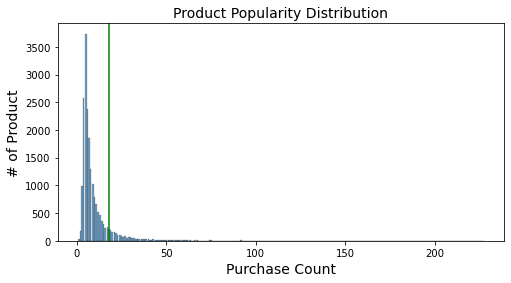

In [5]:
# plot purchase count districution & find the potential threshold
plt.figure(figsize=(8,4))
sns.histplot(x=purchase_count.purchase_count,stat='count',color='steelblue', shrink=2)
plt.title('Product Popularity Distribution', fontsize=14)
plt.ylabel('# of Product', fontsize=14)
plt.xlabel('Purchase Count', fontsize=14)
plt.axvline(x=18,color='green')

In [6]:
extremely_popular_item = purchase_count[purchase_count > popularity_n].dropna()
print('Total # of extremely popular items (ie items bought > {} times): {}'
      .format(popularity_n, len(extremely_popular_item)))

Total # of extremely popular items (ie items bought > 18 times): 2102


### Similarity Analysis


Prepare user category & item category dictionaries 

In [7]:
# get categories per item for similarity analysis
item_category = df[['itemID','categories']].drop_duplicates(subset=['itemID'])
item_category.set_index('itemID',inplace=True)
item_category.head(1)

,categories
itemID,
I402344648,"[[Clothing, Shoes & Jewelry, Women], [Clothing..."


In [8]:
# covert item_category to category string list   
def flatten_list(ls):
    item_category_set=set()
    for subcat in ls:
        for word in subcat:
            item_category_set.add(word)
    return item_category_set

In [9]:
# covert item_category df to dict 
item_cat_dict={}
for i, row in item_category.iterrows():
    if i not in item_cat_dict:
        item_cat_dict[i]=set()
        item_cat_dict[i] = item_cat_dict[i] | flatten_list(row['categories'])
item_cat_dict

{'I402344648': {'Clothing',
  'Clothing, Shoes & Jewelry',
  'Leggings',
  'Novelty',
  'Novelty, Costumes & More',
  'Women'},
 'I697650540': {'Bras',
  'Clothing',
  'Clothing, Shoes & Jewelry',
  'Everyday Bras',
  'Intimates',
  'Lingerie, Sleep & Lounge',
  'Petite',
  'Women'},
 'I464613034': {'Clothing, Shoes & Jewelry',
  'Gifts for the Groomsmen',
  'Novelty',
  'Novelty, Costumes & More',
  'Wedding Party Gifts',
  'Women'},
 'I559560885': {'Clothing',
  'Clothing, Shoes & Jewelry',
  'Cover-Ups',
  'Swimsuits & Cover Ups',
  'Women'},
 'I476005312': {'Band & Music Fan',
  'Clothing',
  'Clothing, Shoes & Jewelry',
  'Knits & Tees',
  'Novelty',
  'Novelty, Costumes & More',
  'Plus-Size',
  'T-Shirts',
  'Tops & Tees',
  'Women'},
 'I342631873': {'Bras',
  'Clothing',
  'Clothing, Shoes & Jewelry',
  'Everyday Bras',
  'Intimates',
  'Lingerie, Sleep & Lounge',
  'Plus-Size',
  'Women'},
 'I773829721': {'B',
  'Birkenstock',
  'Clothing, Shoes & Jewelry',
  'Comfort Shoes',


In [10]:
# get user category dictionary
user_cat_dict={}
for i, row in df.iterrows():
    user,item=row['reviewerID'],row['itemID']
    if user not in user_cat_dict:
        user_cat_dict[user]=set()
    user_cat_dict[user] = user_cat_dict[user] | item_cat_dict[item]
user_cat_dict

{'U490934656': {'Casual',
  'Clothing',
  'Clothing, Shoes & Jewelry',
  'Leggings',
  'Novelty',
  'Novelty, Costumes & More',
  'Plus-Size',
  'Shorts',
  'Women'},
 'U714157797': {'B',
  'Betsey Johnson',
  'Bras',
  'Clothing',
  'Clothing, Shoes & Jewelry',
  'Everyday Bras',
  'Exotic Apparel',
  'Intimates',
  'Jeans',
  'Lingerie, Sleep & Lounge',
  'Novelty, Costumes & More',
  'Petite',
  'Women',
  "Women's Luxury Brands"},
 'U507366950': {'Active',
  'Active Shirts & Tees',
  'Athletic',
  'B',
  'Band & Music Fan',
  'Bella',
  'Birkenstock',
  'Boot Shop',
  'Boots',
  'Bras',
  'C',
  'Capezio',
  'Clothing',
  'Clothing, Shoes & Jewelry',
  'Columbia',
  'Comfort Shoes',
  'D',
  'DV by Dolce Vita',
  'Dance',
  'Everyday Bras',
  'Gifts for the Groomsmen',
  'Girls',
  'Intimates',
  'Jeans',
  'Juniors',
  'Knits & Tees',
  'Leggings',
  'Leotards',
  'Lingerie, Sleep & Lounge',
  'Men',
  'Mules & Clogs',
  'Novelty',
  'Novelty, Costumes & More',
  'Other Sports',
 

**Define similar :** 
 - 1 if common word more than threshold common_k
 - otherwise, 1 if jaccard index > threshold_j ( jaccard index = |A & B| / |A or B| )
 - otherwise, 0 

In [11]:
def similar(user_cat, item_cat):
    if (len(user_cat & item_cat ) > common_k): 
        return 1
    else: 
        return (float(len(user_cat & item_cat)) / len(user_cat | item_cat)) > jaccard_j

### Make prediction

In [12]:
def predict_purchase(user,item):
    
    if i in extremely_popular_item.index:   # popularity 
        return 1
    elif (user not in user_cat_dict or item not in item_cat_dict):  # cold start 
        return 0
    else:     # similarity 
        return similar(user_cat_dict[user],item_cat_dict[item])

### Validate using train data

In [13]:
# Generate balanced train data , assume those not shown in the train data are no-buy
uniq_user = df['reviewerID'].unique().tolist()
uniq_item = df['itemID'].unique().tolist()
non_purchaser = []
unpurchase_item = []
purchase_dict = defaultdict(list)
for index, row in df.iterrows():
    purchase_dict[row['reviewerID']].append(row['itemID'])
while len(non_purchaser) < 200000:
    u = random.choice(uniq_user)
    i = random.choice(uniq_item)
    if i not in purchase_dict[u]:
        non_purchaser.append(u)
        unpurchase_item.append(i)
user_val = df['reviewerID'].tolist() + non_purchaser
item_val = df['itemID'].tolist() + unpurchase_item
actual_val= [1]*200000 + [0]*200000

In [14]:
val_data = pd.DataFrame()
val_data['user']=user_val
val_data['item']=item_val

In [15]:
pred_val=[]
for index, row in val_data.iterrows():
    u,i =  row['user'],row['item']
    if predict_purchase(u,i):
        pred_val.append(1)
    else:
        pred_val.append(0)
accuracy= float(sum([(a == b) for a,b in zip(pred_val, actual_val)]))/len(actual_val)
accuracy

0.8295325

#### Tune parameters

In [16]:
popularity_n = 18
common_k = 4
jaccard_j = 0.185
pred_val=[]
for index, row in val_data.iterrows():
    u,i =  row['user'],row['item']
    if predict_purchase(u,i):
        pred_val.append(1)
    else:
        pred_val.append(0)
accuracy= float(sum([(a == b) for a,b in zip(pred_val, actual_val)]))/len(actual_val)
accuracy

0.8295325

**Limitation:** \
We found the way we generate the validation data have heavy impact to the final result. \
This validation tuning were not fully consistent of the final submission. 

### Generate the final result

In [17]:
predictions = open("predictions_Purchase_2.csv", 'w')
pred_true = 0
pred_false = 0
lines = 0

for l in open("pairs_Purchase.txt"):
    lines += 1
    if l.startswith("reviewerID"):
        #header
        predictions.write(l)
        continue
    u,i = l.strip().split('-')
    
    if predict_purchase(u,i):
        predictions.write(u + '-' + i + ",1\n")
        pred_true += 1
    else:
        predictions.write(u + '-' + i + ",0\n")
        pred_false += 1
            
print ('number of line', lines-1)
print ('predicted_true', pred_true)
print ('predicted_false', pred_false)

predictions.close()

number of line 28000
predicted_true 14525
predicted_false 13475
